
TFG

Este es el codigo del tfg de Borja Jimeno

In [1]:
import sys            # módulo para interactuar con el intérprete
import os             # módulo para operaciones del sistema de archivos

import numpy as np
import math as m
import matplotlib.pyplot as plt
from scipy import special
from scipy.stats import norm
import re

path="/home/borja/Documents/TFG/GeneraRitmo/Libs/ANAIS"
sys.path.append(path)

from funciones_ritmo_teorico import*
from funciones_ritmo_exp import*

plt.rcParams['font.size'] = 18

(7.0, 10.0, 20.0, 40.0, 100.0, 200.0, 1000.0)


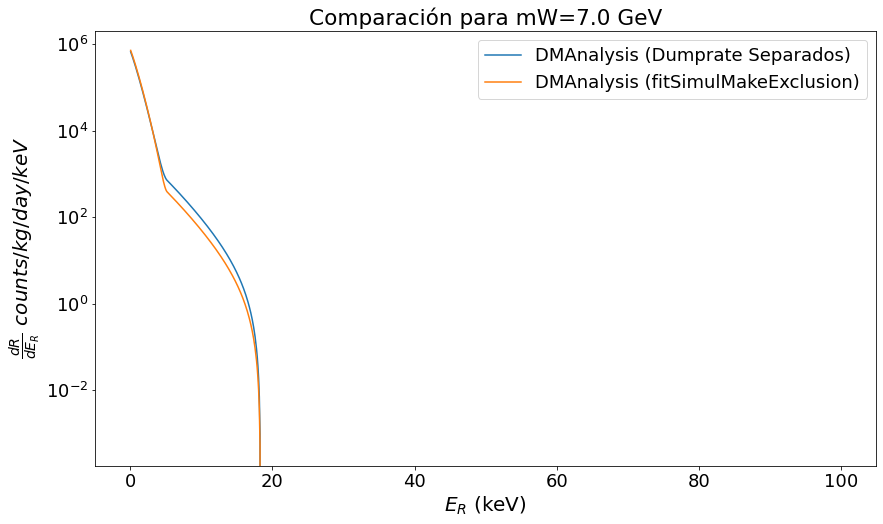

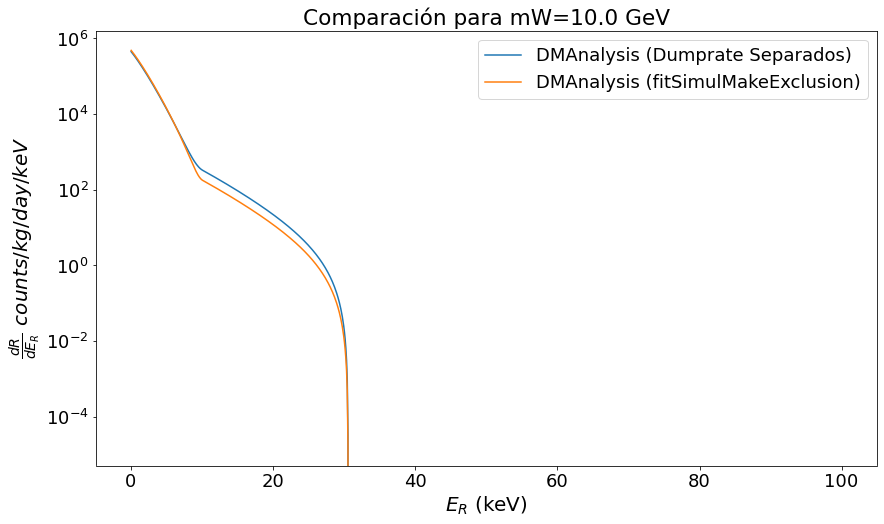

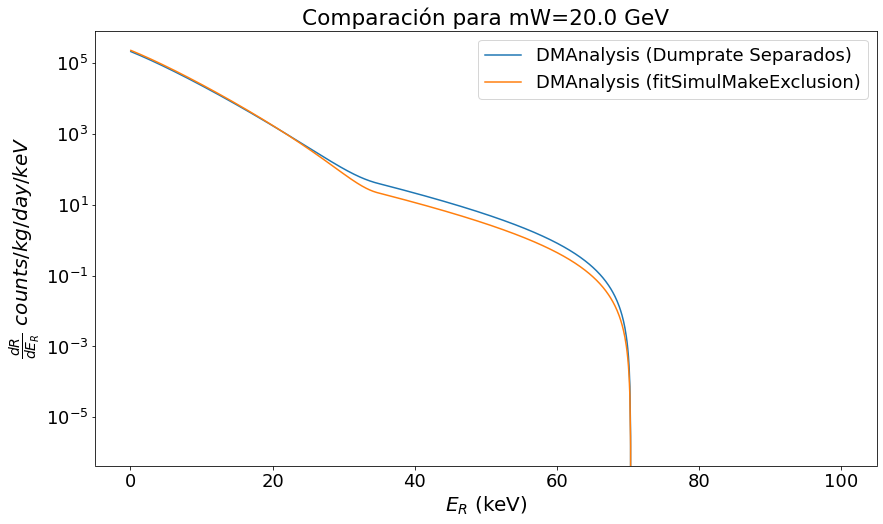

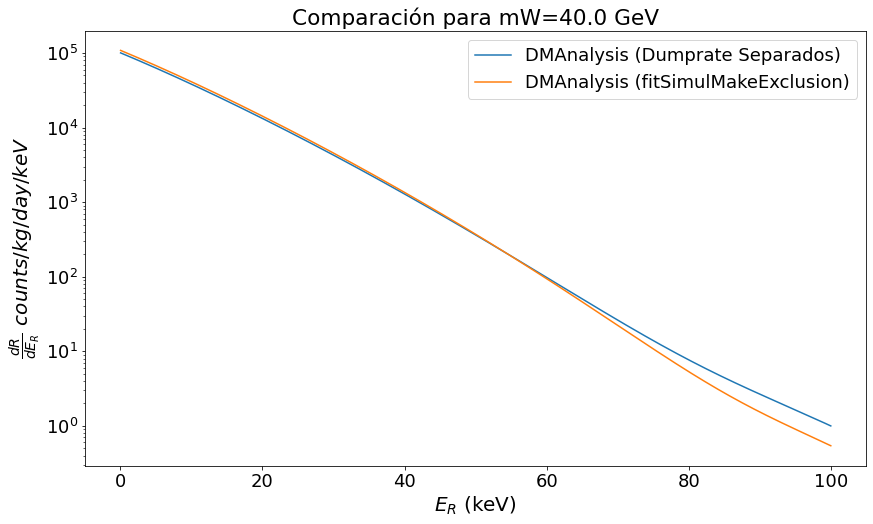

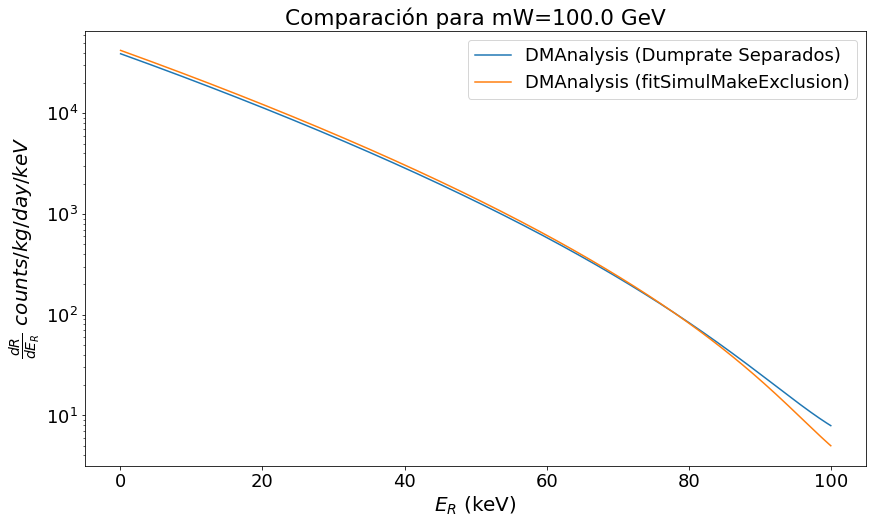

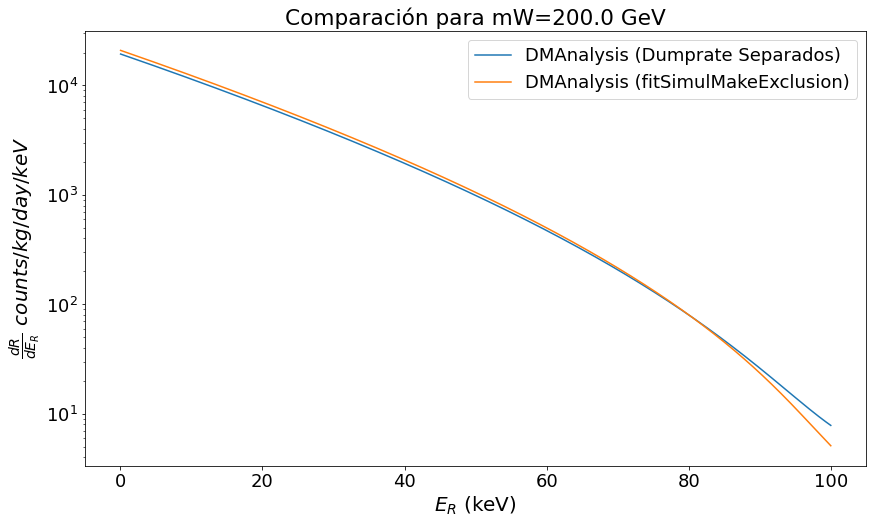

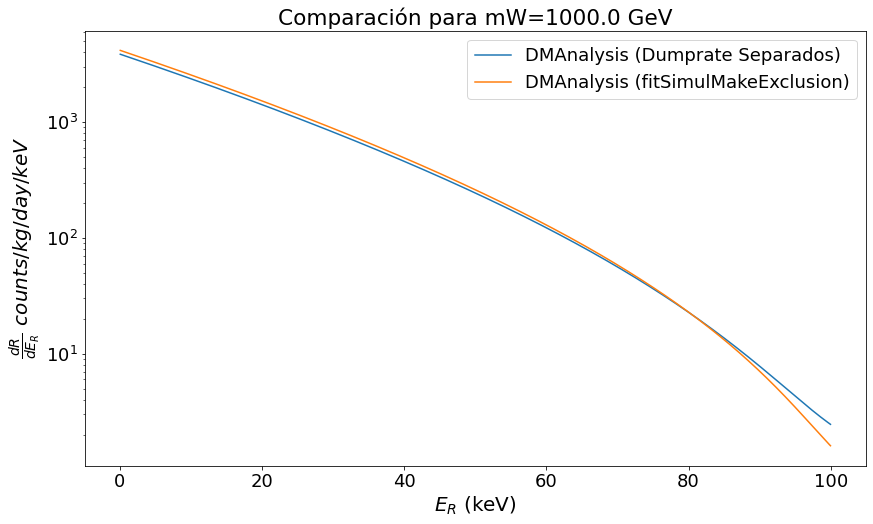

In [8]:
import uproot

array_mw=(7.0,10.0,20.0,40.0,100.0,200.0,1000.0)
print(array_mw)

timeMax=72.9 
timeMin=255.5 
timeAvg=(timeMax+timeMin)/2.

si=1e-36            
ene=np.arange(0,100,0.1)

for mW in array_mw:

        name2="rateDMAnalysis_SI_separados.root"
        file = uproot.open(name2)
        name="SI_rates/rate_SI_"
        name+="Na"
        name+="_mw"
        name+=str(np.round(mW,1))
        hist = file[name]
        bin_content = hist.values()
        data_Na = np.array(bin_content)
        bin_centers = hist.axis().centers()
        ene_Na = np.array(bin_centers)

        name2="rateDMAnalysis_SI_separados.root"
        file = uproot.open(name2)
        name="SI_rates/rate_SI_"
        name+="I"
        name+="_mw"
        name+=str(np.round(mW,1))
        hist = file[name]
        bin_content = hist.values()
        data_I = np.array(bin_content)
        bin_centers = hist.axis().centers()
        ene_I = np.array(bin_centers)

        DM=(23.*data_Na+127.*data_I)/(23.+127.)
        DM_en = ene_I


        name2="rateDMAnalysis_SI_juntos.root"
        file = uproot.open(name2)
        name="SI_rates/rate_SI_JN_mw"
        name+=str(np.round(mW,1))
        hist = file[name]
        bin_content = hist.values()
        DM_2 = np.array(bin_content)
        bin_centers = hist.axis().centers()
        DM_2_en = np.array(bin_centers)
        
        name2="rate_DMAnalysis_SI_fitSim.root"
        file = uproot.open(name2)
        name="rate_SI_mw"
        name+=str(np.round(mW,1))
        hist = file[name]
        bin_content = hist.values()
        DM_3 = np.array(bin_content)
        bin_centers = hist.axis().centers()
        DM_3_en = np.array(bin_centers)




        name2="/home/borja/Documents/TFG/GeneraRitmo/Results/RAPIDD_SI_TH1D.root"
        file = uproot.open(name2)
        nameNA="hist_Na_mw_"
        nameNA+=str(np.round(mW,1))
        nameI="hist_I_mw_"
        nameI+=str(np.round(mW,1))
        hist = file[nameNA]
        bin_content = hist.values()
        rateNA = np.array(bin_content)
        bin_centers = hist.axis().centers()
        eneNA = np.array(bin_centers)
        hist = file[nameI]
        bin_content = hist.values()
        rateI = np.array(bin_content)
        bin_centers = hist.axis().centers()
        eneI = np.array(bin_centers)

        ene_RA=eneI
        rate_NaI_RA=(23.*rateNA+127.*rateI)/(23.+127.)

        name2="/home/borja/Documents/TFG/GeneraRitmo/Results/WIMPYDD_SI_TH1D.root"
        file = uproot.open(name2)
        nameNA="hist_Na_mw_"
        nameNA+=str(np.round(mW,1))
        nameI="hist_I_mw_"
        nameI+=str(np.round(mW,1))
        hist = file[nameNA]
        bin_content = hist.values()
        rateNA = np.array(bin_content)
        bin_centers = hist.axis().centers()
        eneNA = np.array(bin_centers)
        hist = file[nameI]
        bin_content = hist.values()
        rateI = np.array(bin_content)
        bin_centers = hist.axis().centers()
        eneI = np.array(bin_centers)

        ene_WI=eneI
        rate_NaI_WI=(23.*rateNA+127.*rateI)/(23.+127.)

        rate_NaI_PY=np.array([RateNaI(e,timeAvg,mW,si) for e in ene])

        plt.figure(figsize=(14, 8))
        ax = plt.subplot()

        ax.plot(DM_en,DM, linestyle='-',label="DMAnalysis (Dumprate Separados)", alpha=1)
        #ax.plot(DM_2_en,DM_2, linestyle='-',label="DMAnalysis (Dumprate Juntos)", alpha=1)
        ax.plot(DM_3_en,DM_3, linestyle='-',label="DMAnalysis (fitSimulMakeExclusion)", alpha=1)
        #ax.plot(ene,rate_NaI_PY, linestyle='--',label="Python", alpha=0.2)
        #ax.plot(ene_RA,rate_NaI_RA, linestyle='--',label="RAPIDD", alpha=0.2)
        #ax.plot(ene_WI,rate_NaI_WI, linestyle='--',label="WIMPYDD", alpha=0.2)
        ax.legend()

        ax.set_title("Comparación para mW="+str(np.round(mW,1))+" GeV")
        ax.set_ylabel(r'$\frac{dR}{dE_R}$ $counts/kg/day/keV$',fontsize=20)
        ax.set_xlabel(r'$E_R$ (keV)',fontsize=20)

        ax.set_yscale("log")
        #ax.set_xscale("log")


#print(eneI)
